<a href="https://colab.research.google.com/github/ggchu39/3D-microscopy-spatial-analysis-demo/blob/main/3D_microscopy_spatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D Microscopy Spatial Analysis Demo

A training demonstration of a simplified 3D microscopy analysis workflow using **synthetic data**.

The notebook explores core image-analysis concepts relevant to 3D fluorescence microscopy: intensity-based segmentation, segmentation evaluation, connected-component labelling, object-level measurements, multichannel fluorescence quantification, and calibrated 3D object-to-vessel distance analysis.

**Scope:** All image data and biological structures in this notebook are simulated. The workflow is intended to demonstrate image-analysis concepts and Python implementation, not to represent a validated biological or production analysis pipeline.

In [27]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

In [28]:
# Size of our synthetic 3D image: (Z, Y, X)
shape = (20, 80, 80)

# Create a noisy fluorescence-like background
rng = np.random.default_rng(42)

synthetic_cell_channel = rng.normal(
    loc=30,
    scale=5,
    size=shape
)

print("Shape:", synthetic_cell_channel.shape)
print("Minimum intensity:", synthetic_cell_channel.min())
print("Maximum intensity:", synthetic_cell_channel.max())
print("Mean intensity:", synthetic_cell_channel.mean())

Shape: (20, 80, 80)
Minimum intensity: 8.054427075675818
Maximum intensity: 55.03617615954498
Mean intensity: 29.981755072135993


In [29]:
# Create a binary mask that defines three synthetic cell-like regions
true_cell_mask = np.zeros(shape, dtype=bool)

true_cell_mask[8:13, 20:25, 20:25] = True
true_cell_mask[5:10, 45:50, 50:55] = True
true_cell_mask[12:17, 55:60, 30:35] = True

# Make those cell regions brighter in the fluorescence image
synthetic_cell_channel[true_cell_mask] += 120

print("Number of true cell voxels:", true_cell_mask.sum())
print("Mean background intensity:", synthetic_cell_channel[~true_cell_mask].mean())
print("Mean cell intensity:", synthetic_cell_channel[true_cell_mask].mean())

Number of true cell voxels: 375
Mean background intensity: 29.982368613810337
Mean cell intensity: 149.77294638896575


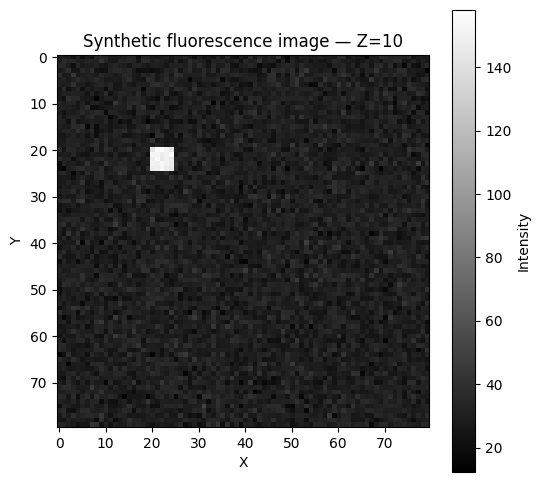

In [30]:
z_view = 10

plt.figure(figsize=(6, 6))

plt.imshow(
    synthetic_cell_channel[z_view],
    cmap="gray"
)

plt.title(f"Synthetic fluorescence image — Z={z_view}")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(label="Intensity")

plt.show()

In [31]:
threshold = 80

predicted_cell_mask = synthetic_cell_channel > threshold

print("Threshold:", threshold)
print("Voxels classified as cell:", predicted_cell_mask.sum())

Threshold: 80
Voxels classified as cell: 375


In [32]:
correct_voxels = np.sum(predicted_cell_mask == true_cell_mask)
total_voxels = true_cell_mask.size

accuracy = correct_voxels / total_voxels

print("Correctly classified voxels:", correct_voxels)
print("Total voxels:", total_voxels)
print("Voxel-wise accuracy:", accuracy)

Correctly classified voxels: 128000
Total voxels: 128000
Voxel-wise accuracy: 1.0


In [33]:
intersection = np.sum(predicted_cell_mask & true_cell_mask)

dice = (
    2 * intersection
    / (predicted_cell_mask.sum() + true_cell_mask.sum())
)

print("Predicted cell voxels:", predicted_cell_mask.sum())
print("True cell voxels:", true_cell_mask.sum())
print("Overlapping cell voxels:", intersection)
print("Dice coefficient:", dice)

Predicted cell voxels: 375
True cell voxels: 375
Overlapping cell voxels: 375
Dice coefficient: 1.0


In [34]:
# Create a more difficult fluorescence-like image
rng = np.random.default_rng(42)

noisy_cell_channel = rng.normal(
    loc=40,
    scale=15,
    size=shape
)

# Add weaker cell signal
noisy_cell_channel[true_cell_mask] += 40

print("Mean background intensity:",
      noisy_cell_channel[~true_cell_mask].mean())

print("Mean cell intensity:",
      noisy_cell_channel[true_cell_mask].mean())

Mean background intensity: 39.94710584143101
Mean cell intensity: 79.31883916689726


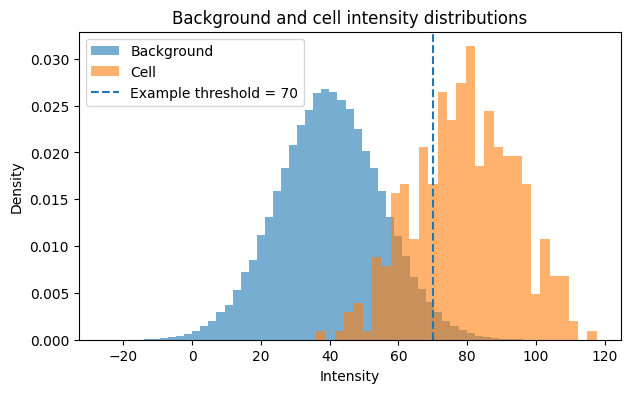

In [35]:
plt.figure(figsize=(7, 4))

plt.hist(
    noisy_cell_channel[~true_cell_mask],
    bins=60,
    density=True,
    alpha=0.6,
    label="Background"
)

plt.hist(
    noisy_cell_channel[true_cell_mask],
    bins=30,
    density=True,
    alpha=0.6,
    label="Cell"
)

plt.axvline(
    70,
    linestyle="--",
    label="Example threshold = 70"
)

plt.xlabel("Intensity")
plt.ylabel("Density")
plt.title("Background and cell intensity distributions")
plt.legend()

plt.show()

In [36]:
predicted_noisy_mask = noisy_cell_channel > 70

true_positive = np.sum(predicted_noisy_mask & true_cell_mask)

false_positive = np.sum(predicted_noisy_mask & ~true_cell_mask)

false_negative = np.sum(~predicted_noisy_mask & true_cell_mask)

dice_noisy = (
    2 * true_positive
    / (2 * true_positive + false_positive + false_negative)
)

print("True positives:", true_positive)
print("False positives:", false_positive)
print("False negatives:", false_negative)
print("Dice coefficient:", dice_noisy)

True positives: 276
False positives: 2983
False negatives: 99
Dice coefficient: 0.1518987341772152


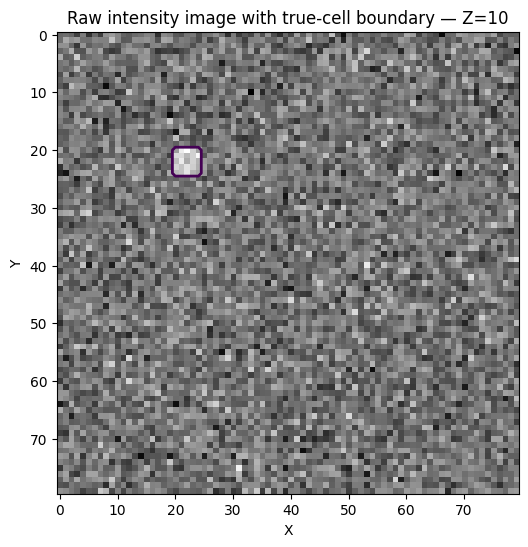

In [37]:
z_view = 10

plt.figure(figsize=(6, 6))

plt.imshow(
    noisy_cell_channel[z_view],
    cmap="gray"
)

plt.contour(
    true_cell_mask[z_view],
    levels=[0.5],
    linewidths=2
)

plt.title(f"Raw intensity image with true-cell boundary — Z={z_view}")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

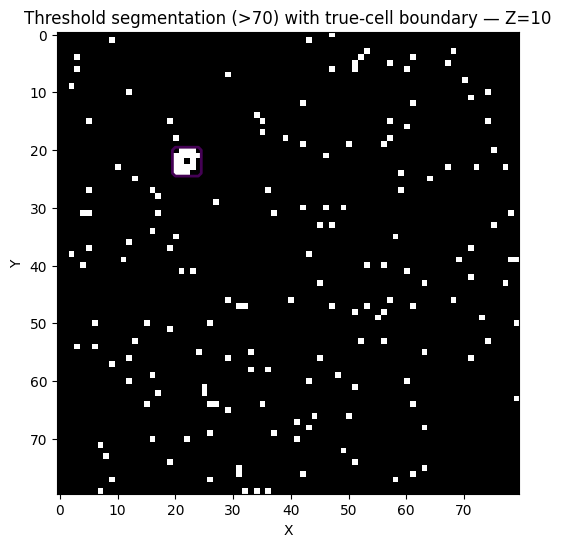

In [38]:
plt.figure(figsize=(6, 6))

plt.imshow(
    predicted_noisy_mask[z_view],
    cmap="gray"
)

plt.contour(
    true_cell_mask[z_view],
    levels=[0.5],
    linewidths=2
)

plt.title(f"Threshold segmentation (>70) with true-cell boundary — Z={z_view}")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [39]:
# Multichannel analysis (Q: HOw can we use the segmentation from one channel to measure signal in another? For each segmented object, what is the mean intensity in the marker channel?)
# Create a second synthetic fluorescence channel
rng = np.random.default_rng(123)

marker_channel = rng.normal(
    loc=20,
    scale=4,
    size=shape
)

# Give the three known cell regions different marker strengths
marker_channel[8:13, 20:25, 20:25] += 80
marker_channel[5:10, 45:50, 50:55] += 30
marker_channel[12:17, 55:60, 30:35] += 5

print("Marker channel shape:", marker_channel.shape)
print("Overall mean marker intensity:", marker_channel.mean())

Marker channel shape: (20, 80, 80)
Overall mean marker intensity: 20.111678184395462


In [40]:
cell_labels, n_cells = ndimage.label(true_cell_mask)

print("Number of labelled cells:", n_cells)

Number of labelled cells: 3


In [41]:
mean_marker_intensity = ndimage.mean(
    marker_channel,
    labels=cell_labels,
    index=range(1, n_cells + 1)
)

print("Mean marker intensity for each cell:")

for cell_id, mean_intensity in enumerate(
    mean_marker_intensity,
    start=1
):
    print(
        "Cell",
        cell_id,
        ":",
        round(mean_intensity, 2)
    )

Mean marker intensity for each cell:
Cell 1 : 50.0
Cell 2 : 100.74
Cell 3 : 25.28


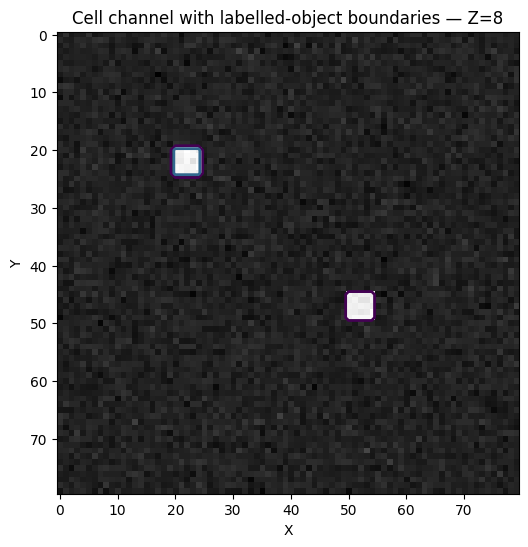

In [42]:
z_view = 8

plt.figure(figsize=(6, 6))

plt.imshow(
    synthetic_cell_channel[z_view],
    cmap="gray"
)

plt.contour(
    cell_labels[z_view],
    levels=[0.5, 1.5, 2.5, 3.5],
    linewidths=2
)

plt.title(f"Cell channel with labelled-object boundaries — Z={z_view}")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

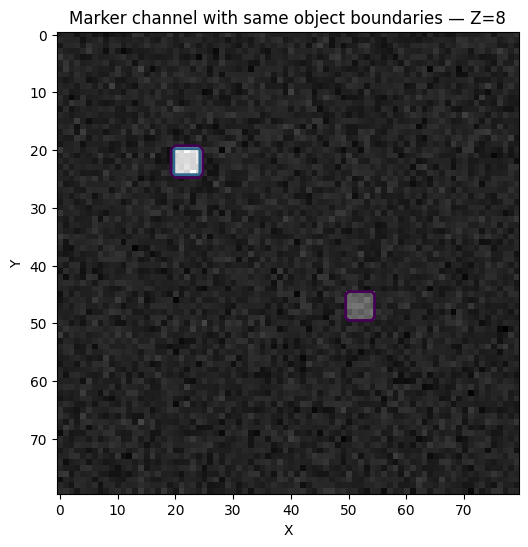

In [43]:
plt.figure(figsize=(6, 6))

plt.imshow(
    marker_channel[z_view],
    cmap="gray"
)

plt.contour(
    cell_labels[z_view],
    levels=[0.5, 1.5, 2.5, 3.5],
    linewidths=2
)

plt.title(f"Marker channel with same object boundaries — Z={z_view}")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [44]:
import pandas as pd

cell_sizes = ndimage.sum(
    true_cell_mask,
    labels=cell_labels,
    index=range(1, n_cells + 1)
)

multichannel_results = []

for cell_id in range(1, n_cells + 1):
    multichannel_results.append({
        "cell_id": cell_id,
        "size_voxels": cell_sizes[cell_id - 1],
        "mean_marker_intensity": mean_marker_intensity[cell_id - 1]
    })

df_multichannel = pd.DataFrame(multichannel_results)

display(df_multichannel.round(2))


,cell_id,size_voxels,mean_marker_intensity
0,1,125.0,50.00
1,2,125.0,100.74
2,3,125.0,25.28


In [45]:
# Create a synthetic vessel mask
vessel_mask = np.zeros(shape, dtype=bool)

# Main horizontal vessel
vessel_mask[:, 38:42, 10:70] = True

# Vertical branch
vessel_mask[:, 42:52, 45:49] = True

print("Vessel mask shape:", vessel_mask.shape)
print("Vessel voxels:", vessel_mask.sum())


Vessel mask shape: (20, 80, 80)
Vessel voxels: 5600


In [46]:
voxel_size_um = (2.0, 0.5, 0.5)  # (Z, Y, X)

In [47]:
vessel_distance_um = ndimage.distance_transform_edt(
    ~vessel_mask,
    sampling=voxel_size_um
)

print("Distance map shape:", vessel_distance_um.shape)
print("Minimum distance:", vessel_distance_um.min(), "µm")
print("Maximum distance:", vessel_distance_um.max(), "µm")

Distance map shape: (20, 80, 80)
Minimum distance: 0.0 µm
Maximum distance: 19.6468827043885 µm


In [48]:
nearest_vessel_um = []

for cell_id in range(1, n_cells + 1):

    cell_distances = vessel_distance_um[
        cell_labels == cell_id
    ]

    nearest_distance = cell_distances.min()

    nearest_vessel_um.append(nearest_distance)

    print(
        "Cell",
        cell_id,
        "nearest vessel distance:",
        round(nearest_distance, 2),
        "µm"
    )

Cell 1 nearest vessel distance: 1.0 µm
Cell 2 nearest vessel distance: 7.0 µm
Cell 3 nearest vessel distance: 5.85 µm


In [49]:
df_multichannel["nearest_vessel_um"] = nearest_vessel_um

display(df_multichannel.round(2))

,cell_id,size_voxels,mean_marker_intensity,nearest_vessel_um
0,1,125.0,50.00,1.00
1,2,125.0,100.74,7.00
2,3,125.0,25.28,5.85


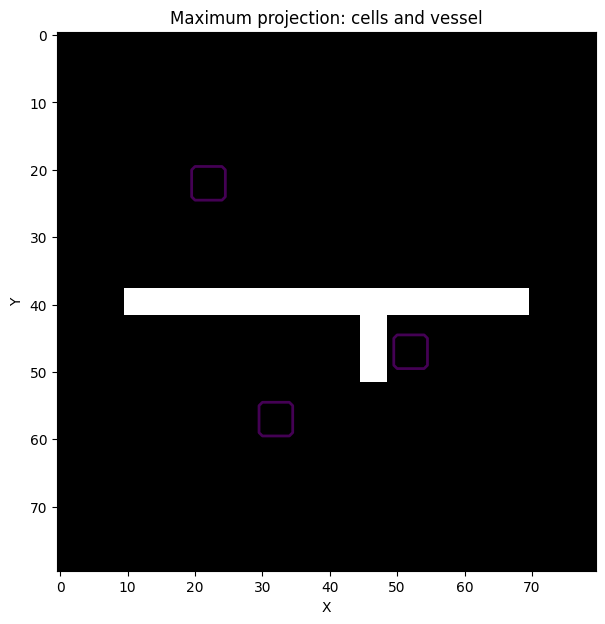

In [50]:
cell_projection = true_cell_mask.max(axis=0)
vessel_projection = vessel_mask.max(axis=0)

plt.figure(figsize=(7, 7))

plt.imshow(
    vessel_projection,
    cmap="gray"
)

plt.contour(
    cell_projection,
    levels=[0.5],
    linewidths=2
)

plt.title("Maximum projection: cells and vessel")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

## Summary

This synthetic demonstration follows a simplified 3D microscopy analysis workflow from fluorescence-like image intensities to object-level and spatial measurements.

The workflow demonstrates:

- generation of a synthetic 3D fluorescence-like intensity volume;
- intensity-based segmentation and comparison with known synthetic ground truth;
- evaluation of segmentation using true positives, false positives, false negatives, and the Dice coefficient;
- connected-component labelling of individual 3D objects;
- object-level voxel counts;
- measurement of mean fluorescence intensity from a second synthetic channel;
- construction of a synthetic vascular mask;
- calibrated 3D Euclidean distance transformation using anisotropic voxel spacing;
- measurement of the nearest object-to-vessel distance; and
- maximum-intensity/binary projection for visual quality control.

The example uses simulated data with known object locations and deliberately simplified geometry. It is intended as a training and reproducibility demonstration rather than a validated biological image-analysis workflow. In real microscopy data, preprocessing, segmentation, calibration, object separation, channel alignment, quality control, and validation would depend on the acquisition method, biological structures, and research question.